In [ ]:
!pip install openml catboost lightgbm optuna

In [134]:
import openml
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

## 1.1 Датасет [Bank](https://www.openml.org/search?type=data&id=1461&sort=runs&status=active)

In [135]:
task = openml.tasks.get_task(233110)
df = task.get_dataset()
X, y, categorical_indicator, attribute_names = df.get_data(target=task.target_name)
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0.0,unknown
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0.0,unknown
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0.0,unknown
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0.0,unknown
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0.0,unknown


In [136]:
le = LabelEncoder()
y = le.fit_transform(y)

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=0, stratify=y)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=.5, random_state=0, stratify=y_test)

## 1.2 Классификация

In [138]:
categorical_features = [name for name, is_cat in zip(attribute_names, categorical_indicator) if is_cat]
numerical_features = [name for name, is_cat in zip(attribute_names, categorical_indicator) if not is_cat]

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('scaling', StandardScaler(), numerical_features)
])

### 1.2.1 LogisticRegression

In [139]:
def objective_lr(trial):
  params = {
      "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
      "C": trial.suggest_categorical("C", [100, 10, 1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5]),
  }
  solver = "liblinear" if params["penalty"] == "l1" else "lbfgs"
  pipeline_lr = Pipeline(steps=[
      ('ohe_and_scaling', column_transformer),
      ('regression', LogisticRegression(**params, solver=solver, max_iter=1000, random_state=0))
  ])
  model_lr = pipeline_lr.fit(X_train, y_train)
  y_pred = model_lr.predict_proba(X_valid)[:, 1]
  return roc_auc_score(y_valid, y_pred)

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=20)
print("Best Logistic Regression params:", study_lr.best_trial.params)
print("Best ROC-AUC(valid) = %.4f" % study_lr.best_trial.value)

[I 2025-03-05 20:35:51,163] A new study created in memory with name: no-name-f1ca5110-4f29-4bac-82a1-632334f58312
[I 2025-03-05 20:35:56,017] Trial 0 finished with value: 0.9002536101694033 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 0 with value: 0.9002536101694033.
[I 2025-03-05 20:35:56,377] Trial 1 finished with value: 0.8703491980531146 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.9002536101694033.
[I 2025-03-05 20:35:56,627] Trial 2 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.0001}. Best is trial 0 with value: 0.9002536101694033.
[I 2025-03-05 20:35:57,079] Trial 3 finished with value: 0.8905253380561541 and parameters: {'penalty': 'l1', 'C': 0.01}. Best is trial 0 with value: 0.9002536101694033.
[I 2025-03-05 20:35:57,325] Trial 4 finished with value: 0.8863128622537456 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 0 with value: 0.9002536101694033.
[I 2025-03-05 20:35:59,547] Trial 5 finished with

Best Logistic Regression params: {'penalty': 'l1', 'C': 0.1}
Best ROC-AUC(valid) = 0.9009


In [141]:
best_lr_params = study_lr.best_trial.params
solver = "liblinear" if best_lr_params["penalty"] == "l1" else "lbfgs"
final_pipeline_lr = Pipeline([
    ('ohe_and_scaling', column_transformer),
    ('regression', LogisticRegression(**best_lr_params, solver=solver, max_iter=1000, random_state=0))
])
final_model_lr = final_pipeline_lr.fit(X_train, y_train)
y_pred_lr = final_model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, final_model_lr.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr))

ROC-AUC = 0.9141
F1 = 0.4419
Accuracy = 0.9011
Precision = 0.6507
Recall = 0.3346


### 1.2.2 Catboost

In [142]:
def objective_catboost(trial):
  params = {
      "depth": trial.suggest_categorical("depth", [2, 4, 6, 8, 10, 12]),
      "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.03, 0.1, 0.3]),
      "l2_leaf_reg": trial.suggest_categorical("l2_leaf_reg", [1e-3, 1e-2, 1e-1, 1.0, 3.0, 6.0, 10.0]),
  }
  pipeline_cb = Pipeline(steps=[
      ('ohe_and_scaling', column_transformer),
      ('classifier', CatBoostClassifier(**params, iterations=1000, random_state=0, verbose=0))
  ])
  model_cb = pipeline_cb.fit(X_train, y_train)
  y_pred = model_cb.predict_proba(X_valid)[:, 1]
  return roc_auc_score(y_valid, y_pred)

study_cb = optuna.create_study(direction="maximize")
study_cb.optimize(objective_catboost, n_trials=20)
print("Best CatBoost params:", study_cb.best_trial.params)
print("Best ROC-AUC (valid) = %.4f" % study_cb.best_trial.value)

[I 2025-03-05 20:36:40,498] A new study created in memory with name: no-name-dc9519fe-5493-4984-874b-0702f4dc1c5d
[I 2025-03-05 20:36:49,326] Trial 0 finished with value: 0.9266476257836848 and parameters: {'depth': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 6.0}. Best is trial 0 with value: 0.9266476257836848.
Training has stopped (degenerate solution on iteration 902, probably too small l2-regularization, try to increase it)
[I 2025-03-05 20:37:00,992] Trial 1 finished with value: 0.9330250433532784 and parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 0.001}. Best is trial 1 with value: 0.9330250433532784.
[I 2025-03-05 20:37:11,203] Trial 2 finished with value: 0.9342909638180616 and parameters: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 0.001}. Best is trial 2 with value: 0.9342909638180616.
[I 2025-03-05 20:37:56,374] Trial 3 finished with value: 0.9181227829230454 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 1.0}. Best is trial 2 with val

Best CatBoost params: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3.0}
Best ROC-AUC (valid) = 0.9356


In [143]:
best_cb_params = study_cb.best_trial.params
final_pipeline_cb = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('classifier', CatBoostClassifier(**best_cb_params, iterations=1000, random_state=0, verbose=0))
])
final_model_cb = final_pipeline_cb.fit(X_train, y_train)
y_pred_cb = final_model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, final_model_cb.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb))

ROC-AUC = 0.9407
F1 = 0.5760
Accuracy = 0.9124
Precision = 0.6642
Recall = 0.5085


### 1.2.3 LightGBM

In [144]:
def objective_lgbm(trial):
  params = {
      "num_leaves": trial.suggest_categorical("num_leaves", [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]),
      "reg_alpha": trial.suggest_categorical("reg_alpha", [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]),
      "reg_lambda": trial.suggest_categorical("reg_lambda", [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]),
      "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.03, 0.1, 0.3]),
  }
  pipeline_lgbm = Pipeline(steps=[
      ('ohe_and_scaling', column_transformer),
      ('classifier', LGBMClassifier(**params, n_estimators=1000, random_state=0, verbose=-1))
  ])
  model_lgbm = pipeline_lgbm.fit(X_train, y_train)
  y_pred = model_lgbm.predict_proba(X_valid)[:, 1]
  return roc_auc_score(y_valid, y_pred)

study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=20)
print("Best LightGBM params:", study_lgbm.best_trial.params)
print("Best ROC-AUC (valid) = %.4f" % study_lgbm.best_trial.value)

[I 2025-03-05 20:47:54,551] A new study created in memory with name: no-name-09c1dd21-ef01-4d82-8291-75e19ccd2627
[I 2025-03-05 20:47:57,976] Trial 0 finished with value: 0.9315602872133985 and parameters: {'num_leaves': 16, 'reg_alpha': 1e-05, 'reg_lambda': 1e-07, 'learning_rate': 0.1}. Best is trial 0 with value: 0.9315602872133985.
[I 2025-03-05 20:48:13,374] Trial 1 finished with value: 0.9241934254510611 and parameters: {'num_leaves': 512, 'reg_alpha': 0.01, 'reg_lambda': 10.0, 'learning_rate': 0.3}. Best is trial 0 with value: 0.9315602872133985.
[I 2025-03-05 20:48:22,793] Trial 2 finished with value: 0.9315967404204994 and parameters: {'num_leaves': 128, 'reg_alpha': 10.0, 'reg_lambda': 10.0, 'learning_rate': 0.01}. Best is trial 2 with value: 0.9315967404204994.
[I 2025-03-05 20:48:26,100] Trial 3 finished with value: 0.9307322786521025 and parameters: {'num_leaves': 32, 'reg_alpha': 10.0, 'reg_lambda': 0.001, 'learning_rate': 0.03}. Best is trial 2 with value: 0.9315967404204

Best LightGBM params: {'num_leaves': 4, 'reg_alpha': 1e-06, 'reg_lambda': 1.0, 'learning_rate': 0.1}
Best ROC-AUC (valid) = 0.9319


In [145]:
best_lgbm_params = study_lgbm.best_trial.params
final_pipeline_lgbm = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('classifier', LGBMClassifier(**best_lgbm_params, n_estimators=1000, random_state=0, verbose=-1))
])
final_model_lgbm = final_pipeline_lgbm.fit(X_train, y_train)
y_pred_lgbm = final_model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, final_model_lgbm.predict_proba(X_test)[:, 1]))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm))

ROC-AUC = 0.9404
F1 = 0.5652
Accuracy = 0.9122
Precision = 0.6719
Recall = 0.4877


## 1.3 Полносвязная нейронная сеть

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [ ]:
for col in categorical_features:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_valid[col] = le.transform(X_valid[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_valid[numerical_features] = scaler.transform(X_valid[numerical_features])
X_test[numerical_features]  = scaler.transform(X_test[numerical_features])

In [ ]:
class BankDataset(Dataset):
  def __init__(self, X, y, categorical_cols):
    X = X.copy()
    self.categorical = X.loc[:, categorical_cols].copy().values.astype(np.int64)
    self.numerical = X.drop(columns=categorical_cols).copy().values.astype(np.float32)
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.numerical[idx], self.categorical[idx], self.y[idx]

In [ ]:
trainset = BankDataset(X_train, y_train, categorical_features)
valset = BankDataset(X_valid, y_valid, categorical_features)
testset  = BankDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [ ]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [ ]:
class TabNN(nn.Module):
    def __init__(self, numeric_count, emb_dims, num_classes=2):
        super(TabNN, self).__init__()

        self.embeddings = nn.ModuleList([nn.Embedding(x, y) for x, y in emb_dims])
        embs_count = sum([y for _, y in emb_dims])

        self.fc1 = nn.Linear(embs_count + numeric_count, 160)
        self.fc2 = nn.Linear(160, 80)
        self.fc3 = nn.Linear(80, 40)
        self.fc4 = nn.Linear(40, num_classes)

        self.bn1 = nn.BatchNorm1d(embs_count + numeric_count)
        self.bn2 = nn.BatchNorm1d(160)
        self.bn3 = nn.BatchNorm1d(80)
        self.bn4 = nn.BatchNorm1d(40)

        self.drop = nn.Dropout(0.2)

    def forward(self, x_num, x_cat):
        emb_list = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_emb = torch.cat(emb_list, dim=1)

        x = torch.cat([x_emb, x_num], dim=1)
        x = self.bn1(x)

        x = self.bn2(self.fc1(x))
        x = F.relu(x)
        x = self.drop(x)

        x = self.bn3(self.fc2(x))
        x = F.relu(x)
        x = self.drop(x)

        x = self.bn4(self.fc3(x))
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc4(x)
        return x

In [ ]:
net = TabNN(len(numerical_features), emb_dims)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

TabNN(
  (embeddings): ModuleList(
    (0): Embedding(12, 6)
    (1): Embedding(3, 2)
    (2): Embedding(4, 2)
    (3-5): 3 x Embedding(2, 1)
    (6): Embedding(3, 2)
    (7): Embedding(12, 6)
    (8): Embedding(4, 2)
  )
  (fc1): Linear(in_features=30, out_features=160, bias=True)
  (fc2): Linear(in_features=160, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=40, bias=True)
  (fc4): Linear(in_features=40, out_features=2, bias=True)
  (bn1): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.2, inplace=False)
)

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def plot_loss_accuracy(train_losses, val_losses, train_acc, val_acc):
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, label='train')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

@torch.no_grad()
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()
    for x_num, x_cat, target in loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        target = target.to(device)

        logits = model(x_num, x_cat)
        loss = F.cross_entropy(logits, target)
        loss_log.append(loss.item())

        acc = (logits.argmax(dim=1) == target).sum() / len(x_num)
        acc_log.append(acc.item())
    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()
    for x_num, x_cat, target in train_loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        logits = model(x_num, x_cat)
        loss = F.cross_entropy(logits, target)
        loss.backward()
        optimizer.step()
        loss_log.append(loss.item())

        acc = (logits.argmax(dim=1) == target).sum() / len(x_num)
        acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []
    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)
        train_loss_log.append(train_loss)
        train_acc_log.append(train_acc)
        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)
        plot_loss_accuracy(train_loss_log, val_loss_log, train_acc_log, val_acc_log)
        if scheduler is not None:
            scheduler.step(val_loss)
    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

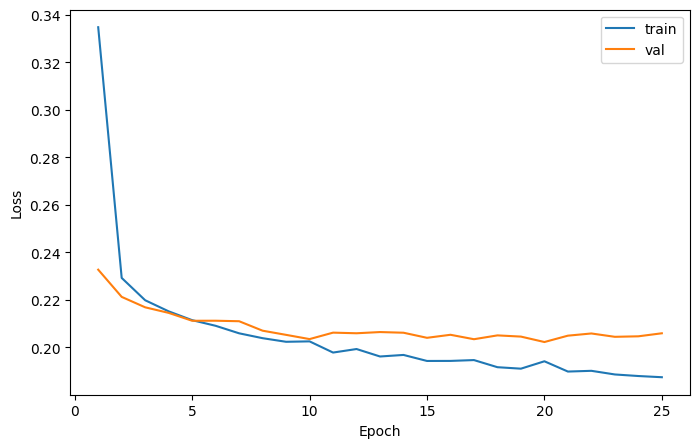

In [ ]:
optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 25, train_loader, val_loader)

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_targets = []
    all_probs = []
    all_preds = []
    for x_num, x_cat, target in loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        target = target.to(device)
        logits = model(x_num, x_cat)
        pos_probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_targets.extend(target)
        all_probs.extend(pos_probs)
        all_preds.extend(preds)
    return np.array(all_targets), np.array(all_probs), np.array(all_preds)

y_true, y_prob, y_pred = evaluate(net, test_loader)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob))
print("F1 = %.4f" % f1_score(y_test, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred))
print("Recall = %.4f" % recall_score(y_test, y_pred))


ROC-AUC = 0.9375
F1 = 0.5899
Accuracy = 0.9062
Precision = 0.6040
Recall = 0.5766
